In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

import math

In [8]:



data = pd.read_csv(
    "../data/features.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,24.883137,-0.007358,-0.007331,25.046606,25.176153,26.631793,27.035149,25.013353,0.147905,-0.540051,...,-0.014235,0.023645,0.007274,0.993473,0.988361,25.889497,24.203715,45.695046,-0.136604,-0.159600
2015-10-19,25.037760,0.006195,0.006214,25.007615,25.159167,26.588194,27.039375,25.015677,0.212889,-0.779835,...,0.014861,-0.004649,0.003617,1.001205,0.995174,25.768494,24.246735,59.838000,-0.118958,-0.151471
2015-10-20,25.494896,0.018093,0.018258,25.011760,25.132500,26.552512,27.049294,25.061317,0.551258,0.082909,...,-0.007358,0.001701,0.004773,1.019316,1.014419,25.782752,24.240768,62.073745,-0.067310,-0.134639
2015-10-21,25.492657,-0.000088,-0.000088,25.005486,25.133710,26.516227,27.059191,25.102397,0.667786,-0.125488,...,0.006195,-0.014235,-0.004773,1.019483,1.014281,25.757509,24.253462,65.300136,-0.026256,-0.112962
2015-10-22,25.882586,0.015180,0.015296,25.011088,25.134875,26.485136,27.069389,25.176701,1.344553,0.112059,...,0.018093,0.014861,-0.011622,1.034844,1.029748,25.788357,24.233819,67.534311,0.037312,-0.082907


In [9]:
series = data["Log_Return"].dropna()

series.describe()

count    2702.000000
mean        0.000958
std         0.018166
min        -0.137708
25%        -0.007215
50%         0.001000
75%         0.010004
max         0.142618
Name: Log_Return, dtype: float64

In [11]:
from statsmodels.tsa.stattools import adfuller


def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("\nStationary series")
    else:
        print("\nNon-stationary series")

In [12]:
adf_test(series)

ADF Statistic: -16.87180884596996
p-value: 1.0796269180485255e-29
Critical Values:
1%: -3.432780577107336
5%: -2.8626138498868667
10%: -2.567341646147285

Stationary series


In [13]:
split = int(len(series)*0.8)

train = series.iloc[:split]

test = series.iloc[split:]

print(len(train))
print(len(test))

2161
541


In [14]:
model = ARIMA(
    train,
    order=(1,0,1)
)

model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Log_Return   No. Observations:                 2161
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5590.516
Date:                Sun, 19 Jul 2026   AIC                         -11173.032
Time:                        22:33:44   BIC                         -11150.318
Sample:                             0   HQIC                        -11164.724
                               - 2161                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.465      0.014       0.000       0.002
ar.L1         -0.0250      0.176     -0.142      0.887      -0.371       0.321
ma.L1         -0.0506      0.180     -0.282      0.778      -0.403       0.302
sigma2         0.0003   5.66e-06     58.538      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2457.43
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.56   Skew:                            -0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [17]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        test.values,
        forecast.values
    )
)


# MAE

mae = mean_absolute_error(
    test.values,
    forecast.values
)


# Direction Accuracy

direction_accuracy = (
    np.sign(test.values)
    ==
    np.sign(forecast.values)
).mean()



print("RMSE:", rmse)

print("MAE:", mae)

print(
    "Direction Accuracy:",
    direction_accuracy
)

RMSE: 0.01777211179551321
MAE: 0.011853904839947471
Direction Accuracy: 0.55637707948244


In [18]:
import itertools
import warnings
warnings.filterwarnings("ignore")


p = range(0,6)
d = range(0,3)
q = range(0,6)


pdq = list(
    itertools.product(
        p,
        d,
        q
    )
)


results = []


for order in pdq:

    try:

        model = ARIMA(
            train,
            order=order
        )

        model_fit = model.fit()

        results.append(
            [
                order,
                model_fit.aic,
                model_fit.bic
            ]
        )

    except:

        continue


arima_results = pd.DataFrame(
    results,
    columns=[
        "Order",
        "AIC",
        "BIC"
    ]
)


arima_results.sort_values(
    "AIC"
).head(10)

,Order,AIC,BIC
59,"(3, 0, 5)",-11211.968445,-11155.185182
77,"(4, 0, 5)",-11210.113235,-11147.651645
95,"(5, 0, 5)",-11208.902093,-11140.762177
46,"(2, 1, 4)",-11201.299419,-11161.554374
47,"(2, 1, 5)",-11198.126714,-11152.703806
64,"(3, 1, 4)",-11195.223987,-11149.801079
45,"(2, 1, 3)",-11194.072670,-11160.005489
65,"(3, 1, 5)",-11193.630873,-11142.530101
23,"(1, 0, 5)",-11188.300635,-11142.874025
41,"(2, 0, 5)",-11188.290346,-11137.185408


#### TRAIN ARIMA (3,0,5)

In [19]:
best_model = ARIMA(
    train,
    order=(3,0,5)
)

best_fit = best_model.fit()

best_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Log_Return   No. Observations:                 2161
Model:                 ARIMA(3, 0, 5)   Log Likelihood                5615.984
Date:                Sun, 19 Jul 2026   AIC                         -11211.968
Time:                        22:42:12   BIC                         -11155.185
Sample:                             0   HQIC                        -11191.200
                               - 2161                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.282      0.022       0.000       0.002
ar.L1         -0.8142      0.211     -3.857      0.000      -1.228      -0.400
ar.L2          0.5887      0.362      1.627      0.104      -0.120       1.298
ar.L3          0.6868      0.190      3.613      0.000       0.314       1.059
ma.L1          0.7459      0.212      3.523      0.000       0.331       1.161
ma.L2         -0.6569      0.349     -1.880      0.060      -1.342       0.028
ma.L3         -0.6916      0.170     -4.072      0.000      -1.024      -0.359
ma.L4          0.0385      0.025      1.556      0.120      -0.010       0.087
ma.L5          0.0829      0.020      4.122      0.000       0.043       0.122
sigma2         0.0003   6.13e-06     52.610      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):              1811.62
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               1.57   Skew:                            -0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
best_forecast = best_fit.forecast(
    steps=len(test)
)

In [21]:
rmse = np.sqrt(
    mean_squared_error(
        test.values,
        best_forecast.values
    )
)


mae = mean_absolute_error(
    test.values,
    best_forecast.values
)


direction_accuracy = (
    np.sign(test.values)
    ==
    np.sign(best_forecast.values)
).mean()


print("RMSE:", rmse)
print("MAE:", mae)
print(
    "Direction Accuracy:",
    direction_accuracy
)

RMSE: 0.017769848137484057
MAE: 0.01185067652308698
Direction Accuracy: 0.55637707948244


In [22]:
ARIMA_baseline = {
    "model": "ARIMA(1,0,1)",
    "RMSE": 0.017772,
    "MAE": 0.011854,
    "Direction Accuracy": 0.5564
}


ARIMA_best = {
    "model": "ARIMA(3,0,5)",
    "RMSE": 0.017770,
    "MAE": 0.011851,
    "Direction Accuracy": 0.5564
}

### Rolling Forecast Validation

In [23]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd

In [24]:
def rolling_arima_forecast(
        train_series,
        test_series,
        order=(3,0,5)
):

    history = list(train_series)

    predictions = []

    for i in range(len(test_series)):

        model = ARIMA(
            history,
            order=order
        )

        model_fit = model.fit()

        forecast = model_fit.forecast(
            steps=1
        )

        prediction = forecast[0]

        predictions.append(
            prediction
        )

        history.append(
            test_series.iloc[i]
        )

    return pd.Series(
        predictions,
        index=test_series.index
    )

In [26]:
def rolling_arima_forecast_fast(
        train_series,
        test_series,
        order=(3,0,5),
        window=500
):

    predictions = []

    history = list(
        train_series[-window:]
    )

    for i in range(len(test_series)):

        model = ARIMA(
            history,
            order=order
        )

        fit = model.fit()

        pred = fit.forecast(
            steps=1
        )[0]

        predictions.append(pred)

        history.append(
            test_series.iloc[i]
        )

        if len(history) > window:
            history.pop(0)

    return pd.Series(
        predictions,
        index=test_series.index
    )

In [27]:
rolling_forecast = rolling_arima_forecast_fast(
    train,
    test,
    order=(3,0,5),
    window=500
)

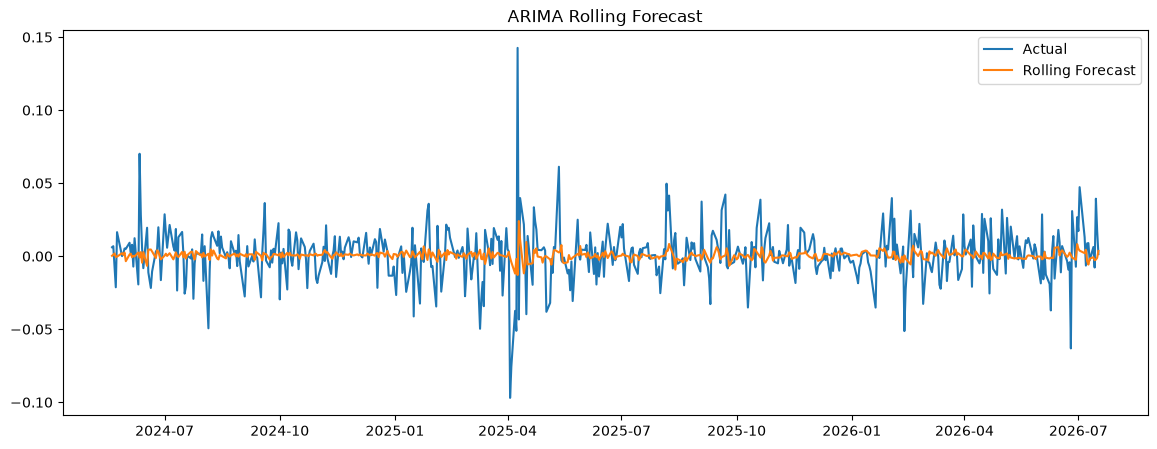

In [28]:
plt.figure(figsize=(14,5))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    rolling_forecast.index,
    rolling_forecast,
    label="Rolling Forecast"
)

plt.legend()

plt.title(
    "ARIMA Rolling Forecast"
)

plt.show()

In [29]:
rolling_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        rolling_forecast.values
    )
)


rolling_mae = mean_absolute_error(
    test.values,
    rolling_forecast.values
)


rolling_direction = (
    np.sign(test.values)
    ==
    np.sign(rolling_forecast.values)
).mean()


print(
    "Rolling RMSE:",
    rolling_rmse
)

print(
    "Rolling MAE:",
    rolling_mae
)

print(
    "Rolling Direction Accuracy:",
    rolling_direction
)

Rolling RMSE: 0.01817274779695573
Rolling MAE: 0.012108506811837103
Rolling Direction Accuracy: 0.5138632162661737


In [30]:
arima_results = {
    "baseline": ...,
    "optimized": ...,
    "rolling": ...
}

In [31]:
arima_results = {
    "ARIMA(1,0,1)": {
        "RMSE": 0.017772,
        "MAE": 0.011854,
        "Direction Accuracy": 0.5564
    },

    "ARIMA(3,0,5)": {
        "RMSE": 0.017770,
        "MAE": 0.011851,
        "Direction Accuracy": 0.5564
    },

    "Rolling ARIMA(3,0,5)": {
        "RMSE": 0.018173,
        "MAE": 0.012109,
        "Direction Accuracy": 0.5139
    }
}

In [32]:
import pickle

with open(
    "arima_results.pkl",
    "wb"
) as f:
    pickle.dump(
        arima_results,
        f
    )